<a href="https://colab.research.google.com/github/propulse-7969/UGP-ML-x-Catalysis/blob/main/EDA_CDM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_excel("../data/raw/filtered_fe_data.xlsx")

In [4]:
df.columns

Index(['Temperature (°C)', 'GHSV (ml/(h*g))', 'CH₄ concentration (%)',
       'Time (min)', 'Calcined temperature (°C)', 'Fe (wt%)', 'Ni (wt%)',
       'Cu (wt%)', 'Co (wt%)', 'Al₂O₃ (wt%)', 'SiO₂ (wt%)', 'TiO₂ (wt%)',
       'MgO (wt%)', 'CH₄ conversion (%)', 'H₂ yield (%)'],
      dtype='str')

In [5]:
df = df.rename(columns={
    'Temperature (°C)': 'reaction_temp',
    'GHSV (ml/(h*g))': 'ghsv',
    'CH₄ concentration (%)': 'ch4_concentration',
    'Time (min)': 'reaction_time',
    'Calcined temperature (°C)': 'calc_temp',

    'Fe (wt%)': 'fe',
    'Ni (wt%)': 'ni',
    'Cu (wt%)': 'cu',
    'Co (wt%)': 'co',

    'Al₂O₃ (wt%)': 'al2o3',
    'SiO₂ (wt%)': 'sio2',
    'TiO₂ (wt%)': 'tio2',
    'MgO (wt%)': 'mgo',

    'CH₄ conversion (%)': 'ch4_conversion',
    'H₂ yield (%)': 'h2_yield'
})

df.columns

Index(['reaction_temp', 'ghsv', 'ch4_concentration', 'reaction_time',
       'calc_temp', 'fe', 'ni', 'cu', 'co', 'al2o3', 'sio2', 'tio2', 'mgo',
       'ch4_conversion', 'h2_yield'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   reaction_temp      648 non-null    int64  
 1   ghsv               648 non-null    int64  
 2   ch4_concentration  648 non-null    float64
 3   reaction_time      648 non-null    float64
 4   calc_temp          648 non-null    int64  
 5   fe                 648 non-null    float64
 6   ni                 648 non-null    float64
 7   cu                 648 non-null    int64  
 8   co                 648 non-null    float64
 9   al2o3              648 non-null    float64
 10  sio2               648 non-null    int64  
 11  tio2               648 non-null    int64  
 12  mgo                648 non-null    float64
 13  ch4_conversion     648 non-null    str    
 14  h2_yield           648 non-null    str    
dtypes: float64(7), int64(6), str(2)
memory usage: 76.1 KB


In [7]:
df = df.replace("-", np.nan)

In [8]:
df["ch4_conversion"] = pd.to_numeric(df["ch4_conversion"], errors="coerce")
df["h2_yield"] = pd.to_numeric(df["h2_yield"], errors="coerce")

In [9]:
df = df.dropna(subset=["h2_yield"])

In [10]:
df = df.reset_index(drop=True)

In [11]:
df = df.fillna(df.median(numeric_only=True))

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   reaction_temp      342 non-null    int64  
 1   ghsv               342 non-null    int64  
 2   ch4_concentration  342 non-null    float64
 3   reaction_time      342 non-null    float64
 4   calc_temp          342 non-null    int64  
 5   fe                 342 non-null    float64
 6   ni                 342 non-null    float64
 7   cu                 342 non-null    int64  
 8   co                 342 non-null    float64
 9   al2o3              342 non-null    float64
 10  sio2               342 non-null    int64  
 11  tio2               342 non-null    int64  
 12  mgo                342 non-null    float64
 13  ch4_conversion     342 non-null    float64
 14  h2_yield           342 non-null    float64
dtypes: float64(9), int64(6)
memory usage: 40.2 KB


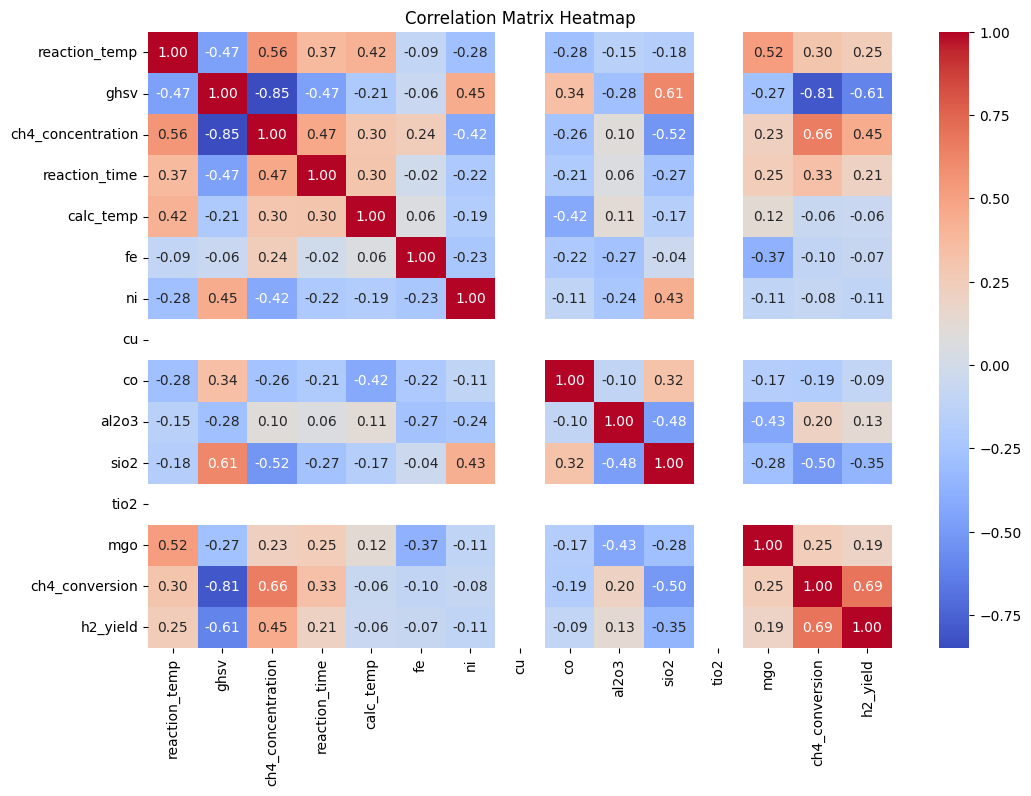

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt


corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

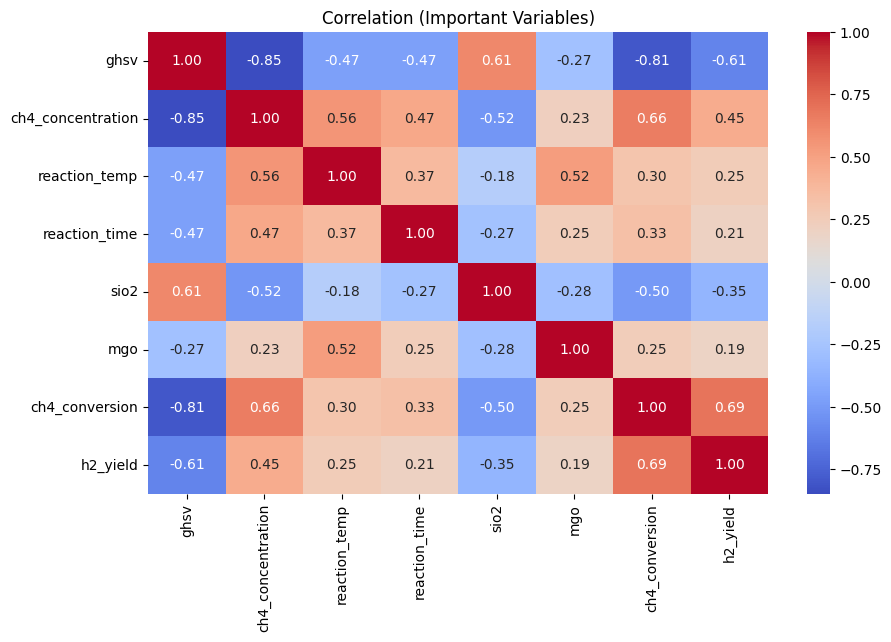

In [14]:
selected_features = [
    "ghsv",
    "ch4_concentration",
    "reaction_temp",
    "reaction_time",
    "sio2",
    "mgo",
    "ch4_conversion",
    "h2_yield"
]

corr_subset = df[selected_features].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_subset, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation (Important Variables)")
plt.show()

First We build a model based on all the features

In [23]:
X=df.drop(columns=["h2_yield", "ch4_conversion"])
y=df["h2_yield"]

In [24]:
print(df["h2_yield"].isnull().sum())

0


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
rf = RandomForestRegressor(
    n_estimators=200,   
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [27]:
y_pred = rf.predict(X_test)

In [28]:
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.9776250163867023
RMSE: 3.580638644794693


Now we build a model based on only the important features, whose correlation is high with respect to H2 yield

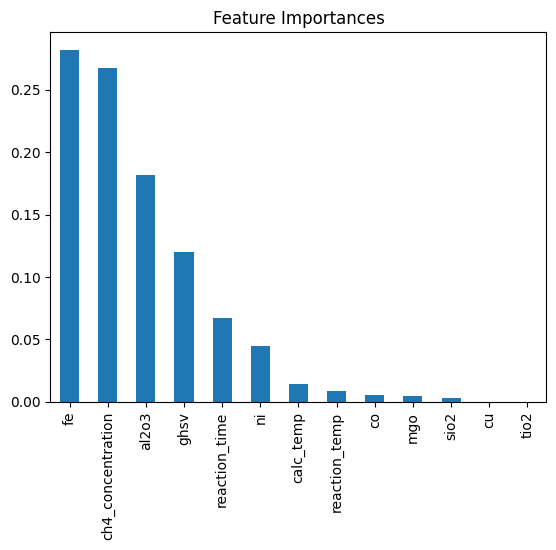

In [29]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importances")
plt.show()